In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# df = pd.read_csv('../diabetes_dataset/diabetes.csv',header=None,usecols=[0,1,2])
# df.columns=['Pregnancies', 'Glucose', 'BloodPressure'] #not necessary for this
df = pd.read_csv('../diabetes_dataset/diabetes.csv')
df = df.iloc[:,:3]


In [11]:
df.sample(5)

,Pregnancies,Glucose,BloodPressure
207,5,162,104
666,4,145,82
131,9,122,56
297,0,126,84
400,4,95,64


/home/shukrina/Documents/vertex/vertex_projects/diabetes_detection/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='BloodPressure', ylabel='Density'>

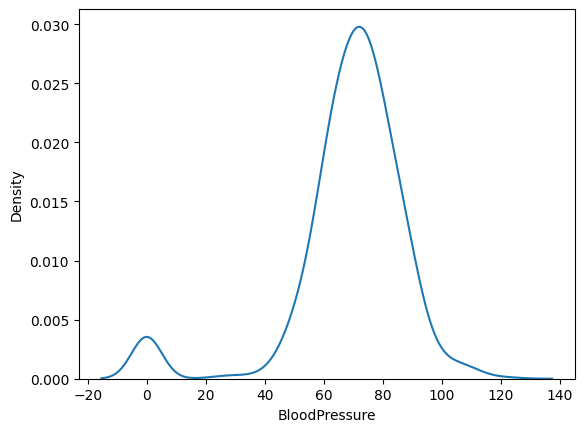

In [13]:
sns.kdeplot(df['BloodPressure'])

/home/shukrina/Documents/vertex/vertex_projects/diabetes_detection/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Glucose', ylabel='Density'>

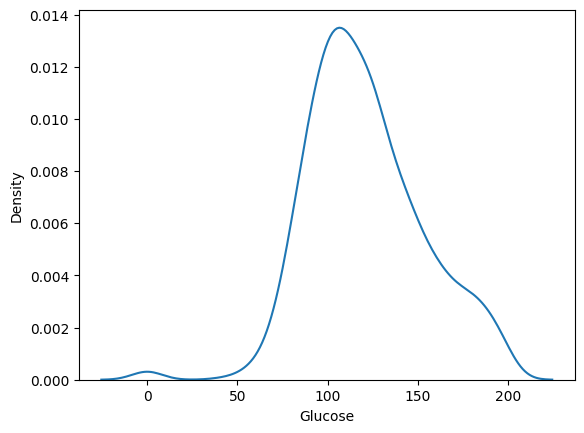

In [15]:
sns.kdeplot(df['Glucose'])

<Axes: xlabel='BloodPressure', ylabel='Glucose'>

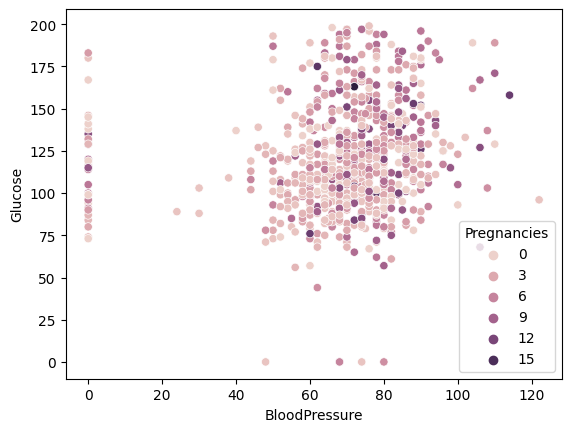

In [18]:
color_dict={1:'red',3:'green',2:'blue'}
sns.scatterplot(x=df['BloodPressure'],y=df['Glucose'],hue=df['Pregnancies'])

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Pregnancies', axis=1),
                                                    df['Pregnancies'],
                                                    test_size=0.3,
                                                    random_state=0)

X_train.shape, X_test.shape

((537, 2), (231, 2))

In [21]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [23]:
np.round(X_train.describe(), 1)

,Glucose,BloodPressure
count,537.0,537.0
mean,121.5,69.7
std,32.2,19.5
min,0.0,0.0
25%,99.0,64.0
50%,118.0,72.0
75%,142.0,80.0
max,198.0,122.0


In [24]:
np.round(X_train_scaled.describe(), 1)

,Glucose,BloodPressure
count,537.0,537.0
mean,0.6,0.6
std,0.2,0.2
min,0.0,0.0
25%,0.5,0.5
50%,0.6,0.6
75%,0.7,0.7
max,1.0,1.0


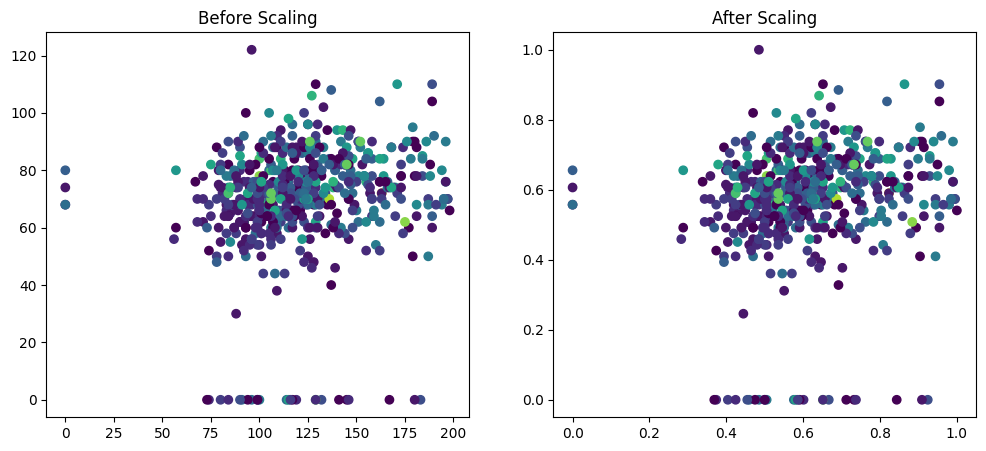

In [26]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Glucose'], X_train['BloodPressure'],c=y_train)
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Glucose'], X_train_scaled['BloodPressure'],c=y_train)
ax2.set_title("After Scaling")
plt.show()

/home/shukrina/Documents/vertex/vertex_projects/diabetes_detection/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/shukrina/Documents/vertex/vertex_projects/diabetes_detection/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/shukrina/Documents/vertex/vertex_projects/diabetes_detection/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/shukrina/Documents/

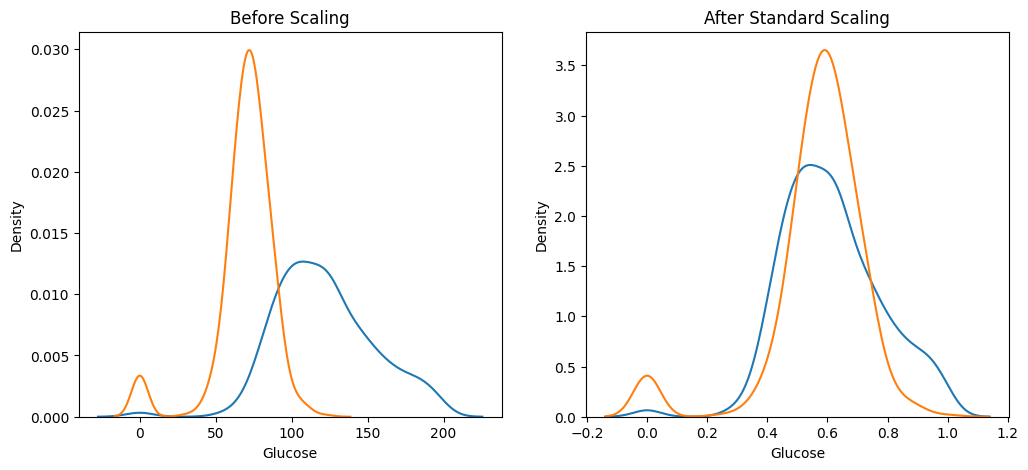

In [27]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Glucose'], ax=ax1)
sns.kdeplot(X_train['BloodPressure'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['Glucose'], ax=ax2)
sns.kdeplot(X_train_scaled['BloodPressure'], ax=ax2)
plt.show()

/home/shukrina/Documents/vertex/vertex_projects/diabetes_detection/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/shukrina/Documents/vertex/vertex_projects/diabetes_detection/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


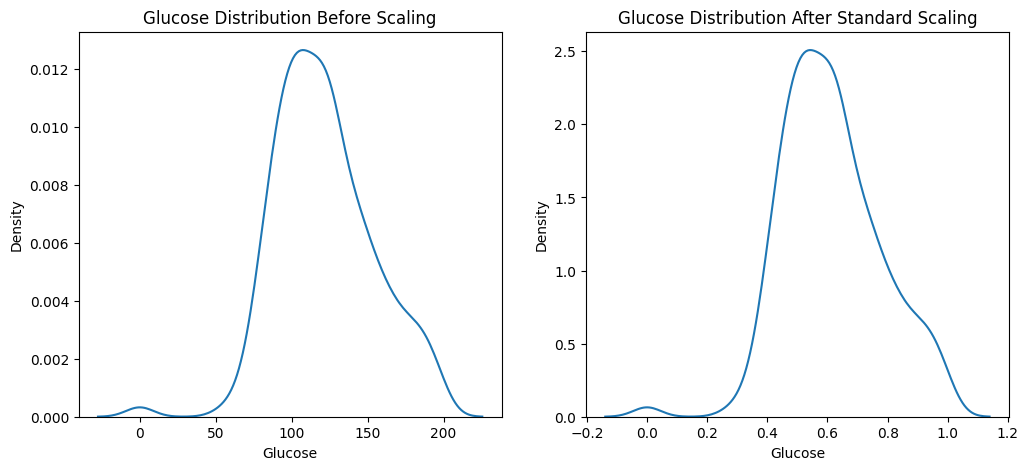

In [28]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Glucose Distribution Before Scaling')
sns.kdeplot(X_train['Glucose'], ax=ax1)

# after scaling
ax2.set_title('Glucose Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Glucose'], ax=ax2)
plt.show()

/home/shukrina/Documents/vertex/vertex_projects/diabetes_detection/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/shukrina/Documents/vertex/vertex_projects/diabetes_detection/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


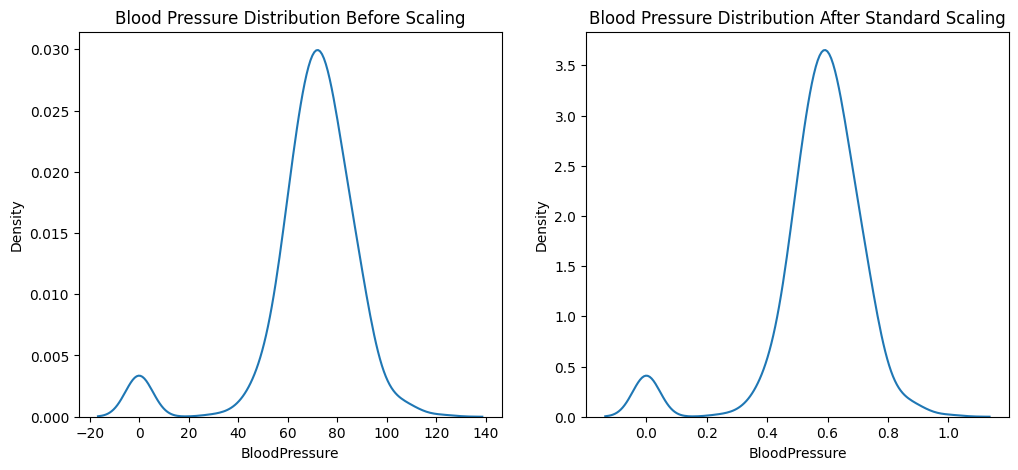

In [30]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Blood Pressure Distribution Before Scaling')
sns.kdeplot(X_train['BloodPressure'], ax=ax1)

# after scaling
ax2.set_title('Blood Pressure Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['BloodPressure'], ax=ax2)
plt.show()